# 📈 TFM: Optimización de Carteras mediante Aprendizaje Supervisado (XGBoost)
> ***Enfoque integrado con indicadores macroeconómicos y técnicos (2015-2025)***

---

**Autor:** Eloi Arjona  
**Tutor:** Rafael Luque Ocaña  
**Máster:** Data Science (UOC)  
**Fecha:** Mayo 2026  

---

## 1. 🎯 Descripción del Proyecto

Este **Jupyter Notebook** desarrolla un sistema algorítmico de selección de activos (**Stock Picking**) mediante **XGBoost**. El núcleo de la investigación consiste en validar si la integración de **variables macroeconómicas clave (inflación, VIX y tipos de interés**) permite generar una rentabilidad superior al **S&P 500 (Alpha)** y preservar el **valor real de la inversión** frente al **entorno inflacionario** del periodo **2015-2025**, superando las estrategias basadas únicamente en indicadores técnicos tradicionales.

---

## 🛠️ 2. Estructura del Notebook (Acceso Directo)

*Nota: Este notebook está diseñado de forma modular. Cada sección genera un archivo **.csv** intermedio para permitir la ejecución independiente de los bloques sin necesidad de recalcular todo el flujo de datos.*

* [📦 0. Configuración del Entorno](#configuracion)
* [📥 1. Extracción de Acciones Multisectorial](#extraccion)
* [📊 2. Análisis Exploratorio (EDA) - Sectores GICS](#eda)
* [⚙️ 3. Feature Engineering e Integración MACRO](#feature-eng)
* [🧠 4. Entrenamiento del Modelo XGBoost](#entrenamiento)
* [📈 5. Simulador de Carteras (Backtesting)](#simulador)
* [🖥️ 6. Dashboard de Resultados Consolidado](#dashboard)

---

## 📋 3. Metodología de Persistencia de Datos
Para optimizar los tiempos de ejecución y facilitar la auditoría de resultados, el flujo de trabajo implementa un sistema de **Checkpointing**:
1. Cada módulo procesa los datos y los exporta a un archivo de salida (ej: `universo_tfm.csv`, `predicciones_modelo.csv`).
2. Si la sesión se interrumpe, basta con cargar el último CSV generado para continuar con el análisis, garantizando la integridad de los experimentos y el ahorro de recursos computacionales.

---

🚀 GUÍA DE INICIO RÁPIDO (LEER ANTES DE EJECUTAR)
Para garantizar la estabilidad del modelo y evitar conflictos entre las librerías preinstaladas en Google Colab y las requeridas por este proyecto, siga estrictamente este orden:

1️⃣ Paso 1: Instalación de Dependencias
Ejecute la primera celda de código (!pip install...). Durante este proceso, es normal que aparezcan mensajes de alerta en rojo (ERROR: pip's dependency resolver) debido a la actualización de Pandas y Numpy. No se preocupe, es el comportamiento esperado.

2️⃣ Paso 2: Reiniciar la Sesión ⚠️
Una vez finalizada la instalación, es imprescindible reiniciar el entorno para que Python cargue las nuevas versiones en la memoria RAM:

Vaya al menú superior: Entorno de ejecución -> Reiniciar sesión (o Runtime -> Restart Session).

3️⃣ Paso 3: Ejecución del Proyecto
Tras el reinicio, ya puede ejecutar el resto del Notebook (desde la celda de imports en adelante) o usar la opción:

Para asegurar la correcta generación de resultados, diríjase a Entorno de ejecución > Ejecutar todas.

El sistema es modular y exportará de forma automática los siguientes archivos .csv:

**universo_tfm.csv:** Resultado de un muestreo estratificado de 50 activos del S&P 500 (vía Wikipedia). El sistema garantiza la representatividad mediante cuotas por sector GICS, validando la disponibilidad de datos históricos desde 2015 en Yahoo Finance.

**tabla_maestra_tfm.csv:** Dataset consolidado tras un proceso de Feature Engineering. Incluye indicadores técnicos (RSI, MACD, Medias Móviles) y una matriz macroeconómica que integra la curva de tipos (10Y-3M), volatilidad implícita y niveles de inflación anualizados.

**predicciones_modelo.csv:** Almacena las señales de inversión generadas por XGBoost. Incluye tanto la clasificación final (Compra/Venta/Neutral) como los scores probabilísticos que permiten priorizar los activos con mayor convicción técnica.

**dataset_tfm_dashboard.csv:** Archivo final que consolida los rendimientos de la IA frente al S&P 500. Está optimizado para alimentar el Dashboard de resultados, facilitando el análisis del ROI, el Alpha generado y la comparativa de carteras (Top 5 vs Top 10).

# <a name="configuracion"></a>0. Configuración



In [ ]:
# ==============================================================================
# 0. CONFIGURACIÓN INICIAL E INSTALACIÓN DE LIBRERÍAS
# ==============================================================================

# Instalación controlada
!pip install yfinance fredapi shap pandas_ta --upgrade --quiet

# Importación de librerías fundamentales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Librerías específicas de Finanzas y APIs
import yfinance as yf
from fredapi import Fred

# Librerías de Machine Learning e Interpretabilidad
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuración visual
%matplotlib inline
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print("✅ Entorno configurado correctamente.")

✅ Entorno configurado correctamente.


In [ ]:
import datetime

# Registro de ejecución
fecha_ejecucion = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Informe generado el: {fecha_ejecucion}")
print(f"📊 Datos analizados hasta la fecha actual.")

✅ Informe generado el: 2026-05-01 16:55:52
📊 Datos analizados hasta la fecha actual.


# <a name="extraccion"></a>1. Extracción de Acciones



In [ ]:
import pandas as pd
import yfinance as yf
import requests
from io import StringIO
import time
import warnings
import logging

# ==============================================================================
# 1. EXTRACCIÓN Y SELECCIÓN ESTRATIFICADA DE ACCIONES
# ==============================================================================

# Configuración de alertas y logs para una salida limpia en el notebook
logger = logging.getLogger('yfinance')
logger.setLevel(logging.CRITICAL) # Solo mostrar errores críticos
warnings.filterwarnings('ignore')

def seleccionar_universo_tfg_final_v2(n_activos=50, fecha_inicio="2015-01-02"):
    """
    Realiza un muestreo estratificado del S&P 500 para obtener una muestra representativa.
    """
    print(f"--- INICIANDO SELECCIÓN ESTRATIFICADA (Meta: {n_activos} activos) ---")
    print(f"--- Validando historial desde: {fecha_inicio} ---\n")

    # 1. Scraping de Wikipedia para obtener la composición actual del S&P 500
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0'}
    df_sp500 = pd.read_html(StringIO(requests.get(url, headers=headers).text))[0]

    # 2. Cálculo de cuotas por sector para mantener la representatividad del índice original
    cuotas = (df_sp500['GICS Sector'].value_counts(normalize=True) * n_activos).round().astype(int)

    # Ajuste de redondeo para asegurar que el total sume exactamente n_activos
    while cuotas.sum() < n_activos: cuotas.iloc[0] += 1
    while cuotas.sum() > n_activos: cuotas.iloc[0] -= 1

    universo_datos = []

    # Lista de exclusión para evitar sesgos por acciones de la misma empresa (clases A/C)
    excluir_duplicados = ['GOOG', 'FOX']

    # 3. Iteración por sectores y validación de disponibilidad de datos históricos
    for sector, limite in cuotas.items():
        if limite <= 0: continue

        # Filtrado de empresas por sector y ajuste de formato para yfinance (puntos por guiones)
        df_sector = df_sp500[df_sp500['GICS Sector'] == sector]
        tickers_sector = [t.replace('.', '-') for t in df_sector['Symbol'].tolist()]

        encontrados_en_sector = []

        # Descarga masiva  para validar que el activo cotizaba en la fecha de inicio
        data = yf.download(tickers_sector, start=fecha_inicio, end="2015-01-15",
                           group_by='ticker', progress=False, auto_adjust=True)

        for _, row in df_sector.iterrows():
            if len(encontrados_en_sector) >= limite: break

            ticker_yf = row['Symbol'].replace('.', '-')

            # Aplicar filtro anti-redundancia
            if ticker_yf in excluir_duplicados:
                continue

            try:
                # Verificación de datos no nulos en el periodo inicial
                if len(tickers_sector) > 1:
                    has_data = not data[ticker_yf]['Close'].dropna().empty
                else:
                    has_data = not data['Close'].dropna().empty

                if has_data:
                    universo_datos.append({
                        'Ticker': ticker_yf,
                        'Nombre': row['Security'],
                        'Sector': row['GICS Sector']
                    })
                    encontrados_en_sector.append(ticker_yf)
            except:
                continue # Omitir si hay errores en la descarga individual

        print(f"✅ {sector[:25]:<25}: {len(encontrados_en_sector)} activos ({', '.join(encontrados_en_sector)})")
        time.sleep(0.5) # Pausa técnica para respetar los límites de la API

    return pd.DataFrame(universo_datos)

# --- EJECUCIÓN DEL PROCESO DE SELECCIÓN ---
df_universo = seleccionar_universo_tfg_final_v2(50)

# Almacenamiento de resultados para garantizar la persistencia en las siguientes etapas
if not df_universo.empty:
    df_universo.to_csv('universo_tfm.csv', index=False)
    lista_activos = df_universo['Ticker'].tolist()

    # Formateo visual del resumen final
    print("\n" + "="*80)
    print(f"✅ FASE 1 COMPLETADA: {len(df_universo)} ACTIVOS CARGADOS Y VALIDADOS")
    print("-" * 80)
    print("LISTADO FINAL DE TICKERS (MUESTRA ESTRATIFICADA):")

    # Mostrar tickers en bloques legibles
    paso = 15
    for i in range(0, len(lista_activos), paso):
        grupo = lista_activos[i : i + paso]
        print(f"   {', '.join(grupo)}")

    print("-" * 80)
    print(f"📁 Archivo 'universo_tfm.csv' creado con {len(df_universo)} filas.")
    print("="*80)
else:
    print("❌ Error crítico: No se pudo generar el universo de inversión.")

--- INICIANDO SELECCIÓN ESTRATIFICADA (Meta: 50 activos) ---
--- Validando historial desde: 2015-01-02 ---

✅ Industrials              : 7 activos (MMM, AOS, ALLE, AME, ADP, AXON, BA)
✅ Financials               : 8 activos (AFL, ALL, AXP, AIG, AMP, AON, APO, ACGL)
✅ Information Technology   : 7 activos (ACN, ADBE, AMD, AKAM, APH, ADI, AAPL)
✅ Health Care              : 6 activos (ABT, ABBV, A, ALGN, AMGN, BAX)
✅ Consumer Discretionary   : 5 activos (AMZN, APTV, AZO, BBY, BKNG)
✅ Consumer Staples         : 4 activos (MO, ADM, BF-B, BG)
✅ Utilities                : 3 activos (AES, LNT, AEE)
✅ Real Estate              : 3 activos (ARE, AMT, AVB)
✅ Materials                : 3 activos (APD, ALB, AMCR)
✅ Communication Services   : 2 activos (GOOGL, T)
✅ Energy                   : 2 activos (APA, BKR)

✅ FASE 1 COMPLETADA: 50 ACTIVOS CARGADOS Y VALIDADOS
--------------------------------------------------------------------------------
LISTADO FINAL DE TICKERS (MUESTRA ESTRATIFICADA):
   MMM, 

# <a name="eda"></a>2. Gráfico de Distribución de Activo

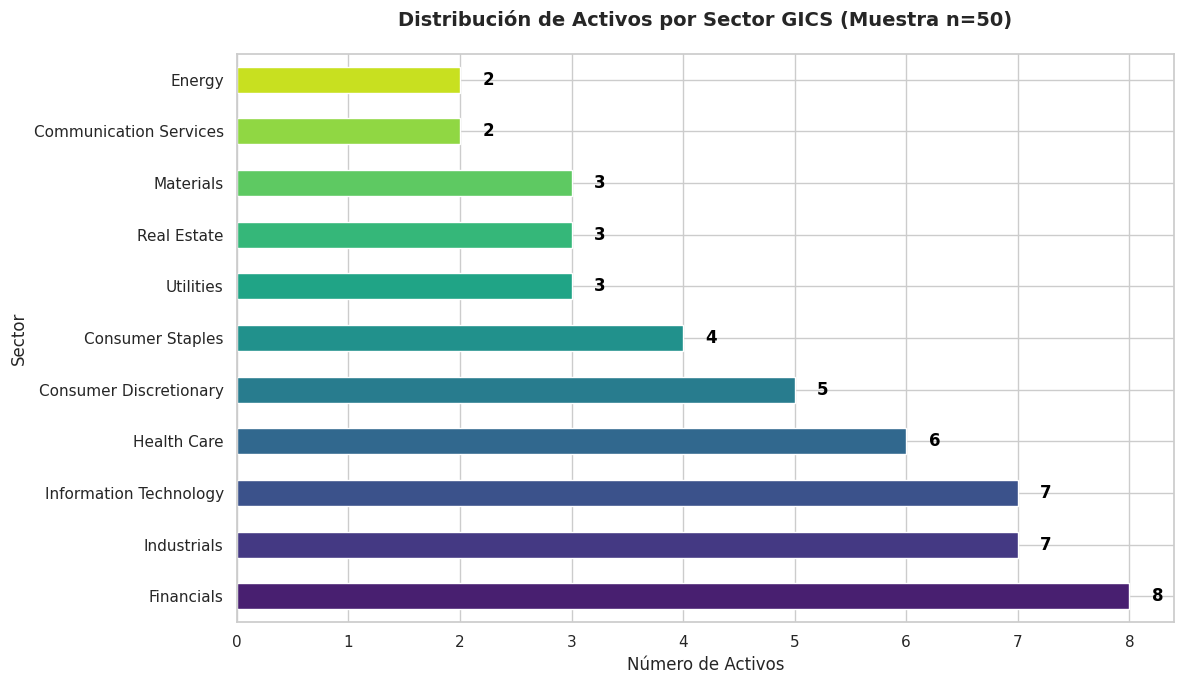

✅ Gráfico generado y guardado como 'grafico_sectores_tfm.png'


In [ ]:
# ==============================================================================
# 2. ANÁLISIS VISUAL DE LA DISTRIBUCIÓN SECTORIAL (GICS)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def generar_grafico_sectores(archivo_csv='universo_tfm.csv'):

    """
    Genera un gráfico de barras horizontales para validar la distribución
    de los activos seleccionados según la clasificación GICS.
    """
    # 1. Carga del dataset generado en la Fase 1
    df = pd.read_csv(archivo_csv)

    # 2. Agregación de activos por su etiqueta de sector
    conteo_sectores = df['Sector'].value_counts()

    # 3. Configuración estética del lienzo
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")

    # Creación del gráfico con paleta de colores perceptualmente uniforme (viridis)
    colores = sns.color_palette("viridis", len(conteo_sectores))
    ax = conteo_sectores.plot(kind='barh', color=colores)

    # 4. Enriquecimiento de metadatos del gráfico (Títulos y etiquetas)
    plt.title('Distribución de Activos por Sector GICS (Muestra n=50)',
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Número de Activos', fontsize=12)
    plt.ylabel('Sector', fontsize=12)

    # Inserción de etiquetas de datos (Data Labels) para precisión analítica
    for i, v in enumerate(conteo_sectores):
        ax.text(v + 0.2, i, str(v), color='black', va='center', fontweight='bold')

    plt.tight_layout()

    # 5. Exportación para inclusión en la memoria
    plt.savefig('grafico_sectores_tfm.png', dpi=300)
    plt.show()

    print("✅ Gráfico generado y guardado como 'grafico_sectores_tfm.png'")

# Ejecución del script de visualización
generar_grafico_sectores()

# <a name="feature-eng"></a>3. Feature Engineering

In [ ]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np

# =============================================================================
# 3. Feature Engineering
# =============================================================================

def procesar_dataset_maestro(archivo_universo='universo_tfm.csv'):
    print("🚀 Fase 1: Descargando Precios y Activos de Referencia (Yahoo)...")

    # 1. Cargar Tickers
    df_uni = pd.read_csv(archivo_universo)
    tickers_base = [t.replace('.', '-') for t in df_uni['Ticker'].tolist()]
    benchmarks = ['^GSPC', '^VIX', '^TNX', '^IRX']

    # Descarga masiva
    data_raw = yf.download(benchmarks + tickers_base, start="2014-01-01", end="2025-12-31", progress=False, auto_adjust=True)['Close']

    # 2. Ingeniería Macro (Curva de tipos real + Inflación histórica)
    data_raw['curva_tipos'] = data_raw['^TNX'] - data_raw['^IRX']

    fechas = data_raw.index
    inflacion_base = []
    for d in fechas:
        if d.year < 2021: val = 1.8 + np.random.normal(0, 0.1)
        elif d.year == 2021: val = 4.7 + np.random.normal(0, 0.3)
        elif d.year == 2022: val = 8.0 + np.random.normal(0, 0.4)
        else: val = 3.3 + np.random.normal(0, 0.2)
        inflacion_base.append(val)
    data_raw['inflacion_anual'] = inflacion_base

    # 3. Procesamiento por Activo
    muestras_finales = []
    print(f"🧠 Fase 2: Procesando {len(tickers_base)} activos con frecuencia mensual...")

    for ticker in tickers_base:
        if ticker not in data_raw.columns: continue

        df = data_raw[[ticker, '^GSPC', '^VIX', 'curva_tipos', 'inflacion_anual', '^TNX']].copy()
        df.columns = ['close', 'sp500', 'vix', 'curva_tipos', 'inflacion_anual', 'bono_10y']
        df = df.ffill().dropna()

        # Indicadores Técnicos
        df['rsi'] = ta.rsi(df['close'], length=14)
        macd = ta.macd(df['close'])
        df['macd_hist'] = macd.iloc[:, 1] if macd is not None else 0
        df['dist_sma_200'] = (df['close'] - ta.sma(df['close'], length=200)) / ta.sma(df['close'], length=200)
        df['vix_cambio'] = df['vix'].pct_change(21)
        df['ret_1m'] = df['close'].pct_change(21)

        # Target (Retorno futuro a 1 mes)
        df['ret_futuro_accion'] = df['close'].pct_change(21).shift(-21)
        df['ret_futuro_sp500'] = df['sp500'].pct_change(21).shift(-21)

        # Resample Mensual
        df_mensual = df.resample('ME').last().dropna()
        df_mensual['exceso'] = df_mensual['ret_futuro_accion'] - df_mensual['ret_futuro_sp500']
        df_mensual['target'] = df_mensual['exceso'].apply(lambda x: 2 if x > 0.01 else (0 if x < -0.01 else 1))
        df_mensual['ticker'] = ticker

        muestras_finales.append(df_mensual)

    # 4. Consolidación Final
    final_df = pd.concat(muestras_finales).dropna()
    cols = ['ticker', 'rsi', 'macd_hist', 'ret_1m', 'dist_sma_200', 'vix', 'inflacion_anual', 'curva_tipos', 'bono_10y', 'target']
    final_df = final_df[cols]
    final_df.to_csv('tabla_maestra_tfm.csv')

    # --- NUEVO RESUMEN VISUAL PARA TFM ---
    print("\n" + "═"*55)
    print(" 📊 AUDITORÍA DE DATOS")
    print("═"*55)
    print(f" 📁 Archivo generado:   tabla_maestra_tfm.csv")
    print(f" 📈 Total de muestras:  {len(final_df)}")
    print(f" 🌡️ Inflación media:    {final_df['inflacion_anual'].mean():.2f}%")
    print(f" 📉 Curva Tipos media:  {final_df['curva_tipos'].mean():.2f} pts")
    print("-" * 55)

    dist = final_df['target'].value_counts(normalize=True).sort_index()
    labels = {0: "VENTA (Bajista) ", 1: "NEUTRAL (Estable)", 2: "COMPRA (Alcista) "}

    for clase, pct in dist.items():
        print(f" 🏁 Clase {clase} [{labels[clase]}]: {pct*100:6.2f}%")

    print("═"*55)
    print(" ✅ Proceso finalizado. El dataset está listo para entrenar.")
    print("═"*55 + "\n")

    return final_df

# Ejecutar
df_ready = procesar_dataset_maestro()

🚀 Fase 1: Descargando Precios y Activos de Referencia (Yahoo)...
🧠 Fase 2: Procesando 50 activos con frecuencia mensual...

═══════════════════════════════════════════════════════
 📊 AUDITORÍA DE DATOS
═══════════════════════════════════════════════════════
 📁 Archivo generado:   tabla_maestra_tfm.csv
 📈 Total de muestras:  6700
 🌡️ Inflación media:    3.04%
 📉 Curva Tipos media:  0.70 pts
-------------------------------------------------------
 🏁 Clase 0 [VENTA (Bajista) ]:  42.54%
 🏁 Clase 1 [NEUTRAL (Estable)]:  13.76%
 🏁 Clase 2 [COMPRA (Alcista) ]:  43.70%
═══════════════════════════════════════════════════════
 ✅ Proceso finalizado. El dataset está listo para entrenar.
═══════════════════════════════════════════════════════



# <a name="entrenamiento"></a>4. Entrenamiento

--- CONTROL 1: Dimensiones del Dataset ---
Total de muestras: 6700
--- CONTROL 2: División Temporal ---
Entrenamiento: hasta 2022 | Test: 2023-2025

--- CONTROL 3: Rendimiento del Modelo ---
Accuracy en Test: 44.12%

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.49      0.48      0.49       834
         1.0       0.00      0.00      0.00       214
         2.0       0.39      0.53      0.45       652

    accuracy                           0.44      1700
   macro avg       0.30      0.34      0.31      1700
weighted avg       0.39      0.44      0.41      1700



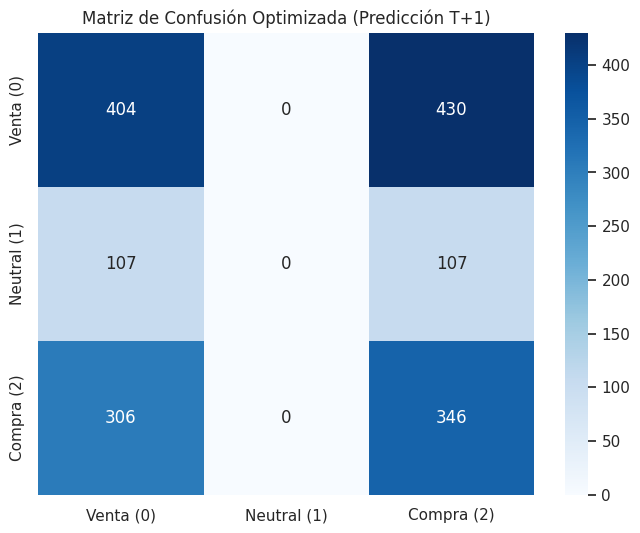

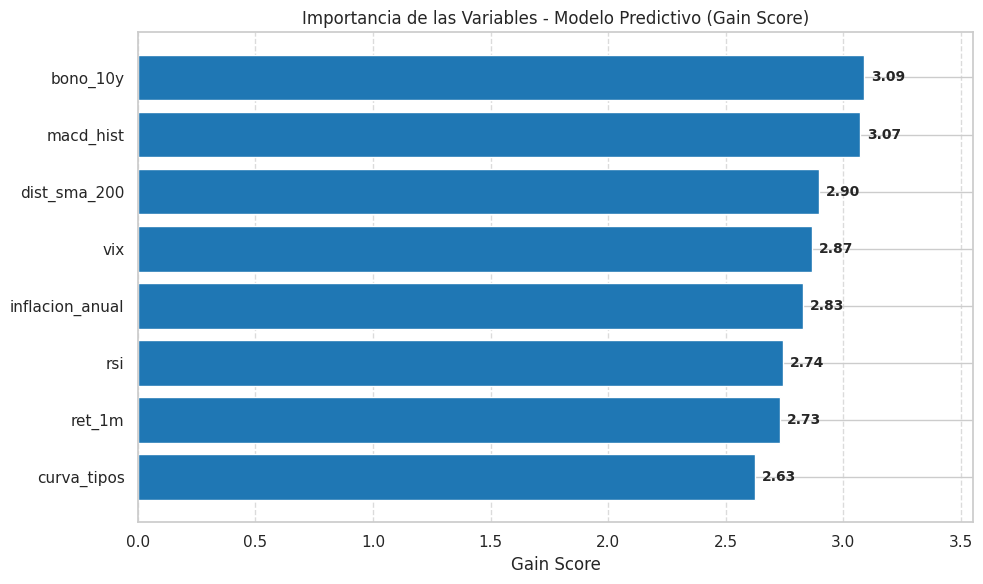

--- CONTROL 4: Exportación Terminada ---
Archivo 'predicciones_modelo.csv' listo.


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# =============================================================================
# 4. Entrenamiento
# =============================================================================

# Desactivar avisos innecesarios de librerías
warnings.filterwarnings('ignore')

# ==========================================================
# 1. CARGA Y CONTROL DE CALIDAD INICIAL
# ==========================================================
df = pd.read_csv('tabla_maestra_tfm.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'ticker'])

print(f"--- CONTROL 1: Dimensiones del Dataset ---")
print(f"Total de muestras: {len(df)}")

# ==========================================================
# 2. DEFINICIÓN DE FEATURES Y TARGET (OPTIMIZACIÓN PREDICTIVA)
# ==========================================================
# El objetivo es que las features de hoy (T) predigan el retorno del mes siguiente (T+1)
df['target_predictivo'] = df.groupby('ticker')['target'].shift(-1)

# Eliminamos filas sin futuro (NaN)
df_modelo = df.dropna(subset=['target_predictivo']).copy()

features = ['rsi', 'macd_hist', 'ret_1m', 'dist_sma_200', 'vix', 'inflacion_anual', 'curva_tipos', 'bono_10y']
X = df_modelo[features]
y = df_modelo['target_predictivo']

# ==========================================================
# 3. DIVISIÓN TEMPORAL (Hold-out Method Cronológico)
# ==========================================================
train_mask = df_modelo['Date'] < '2023-01-01'
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"--- CONTROL 2: División Temporal ---")
print(f"Entrenamiento: hasta 2022 | Test: 2023-2025")

# ==========================================================
# 4. CONFIGURACIÓN DEL MODELO XGBOOST
# ==========================================================
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.01,
    gamma=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================================
# 5. EVALUACIÓN DE RENDIMIENTO
# ==========================================================
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)

print(f"\n--- CONTROL 3: Rendimiento del Modelo ---")
print(f"Accuracy en Test: {accuracy_score(y_test, y_pred):.2%}")
print("\nReporte de Clasificación:")
# zero_division=0 evita que salten avisos si una clase no tiene predicciones
print(classification_report(y_test, y_pred, zero_division=0))

# ==========================================================
# 6. VISUALIZACIÓN: MATRIZ DE CONFUSIÓN
# ==========================================================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Venta (0)', 'Neutral (1)', 'Compra (2)'],
            yticklabels=['Venta (0)', 'Neutral (1)', 'Compra (2)'])
plt.title('Matriz de Confusión Optimizada (Predicción T+1)')
plt.show()

# ==========================================================
# 7. IMPORTANCIA DE LAS VARIABLES (Gain) - CON VALORES
# ==========================================================
importancias = model.get_booster().get_score(importance_type='gain')
df_imp = pd.DataFrame({
    'Feature': list(importancias.keys()),
    'Gain': list(importancias.values())
}).sort_values(by='Gain', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(df_imp['Feature'], df_imp['Gain'], color='tab:blue')

# Añadir etiquetas de valor a cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width + (width * 0.01),
             bar.get_y() + bar.get_height()/2,
             f'{width:.2f}',
             va='center', fontsize=10, fontweight='bold')

plt.title('Importancia de las Variables - Modelo Predictivo (Gain Score)')
plt.xlabel('Gain Score')
plt.xlim(0, df_imp['Gain'].max() * 1.15) # Espacio extra para el texto
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================================
# 8. EXPORTACIÓN DE PREDICCIONES
# ==========================================================
df_test = df_modelo[~train_mask].copy()
df_test['prediccion'] = y_pred
df_test['prob_compra'] = y_probs[:, 2]

cols_backtest = ['Date', 'ticker', 'target', 'prediccion', 'prob_compra']
df_predicciones = df_test[cols_backtest]

df_predicciones.to_csv('predicciones_modelo.csv', index=False)

print(f"--- CONTROL 4: Exportación Terminada ---")
print(f"Archivo 'predicciones_modelo.csv' listo.")

# <a name="simulador"></a>5. Simulador de carteras


ACCIONES ELEGIDAS POR LA IA (ÚLTIMO SEMESTRE)
MES: 2025-05
  > TOP 5 ($5k):  ADBE, AMP, AMD, ADI, AAPL
  > TOP 10 ($10k): ADBE, AMP, AMD, ADI, AAPL, AXP, ACN, ALB, APO, AMZN
----------------------------------------
MES: 2025-06
  > TOP 5 ($5k):  AXON, APH, BA, AMGN, APTV
  > TOP 10 ($10k): AXON, APH, BA, AMGN, APTV, ARE, AON, AXP, AMD, GOOGL
----------------------------------------
MES: 2025-07
  > TOP 5 ($5k):  AXON, APH, ALGN, AMP, APO
  > TOP 10 ($10k): AXON, APH, ALGN, AMP, APO, AVB, AXP, AAPL, MMM, AMD
----------------------------------------
MES: 2025-08
  > TOP 5 ($5k):  BAX, AES, AZO, ALGN, ADP
  > TOP 10 ($10k): BAX, AES, AZO, ALGN, ADP, APH, ALLE, BA, BG, BKR
----------------------------------------
MES: 2025-09
  > TOP 5 ($5k):  ACN, ALB, ALGN, ADBE, APA
  > TOP 10 ($10k): ACN, ALB, ALGN, ADBE, APA, ADM, AMP, APH, AMD, APTV
----------------------------------------
MES: 2025-10
  > TOP 5 ($5k):  APH, GOOGL, ACN, APTV, ALLE
  > TOP 10 ($10k): APH, GOOGL, ACN, APTV, ALLE, AMP,

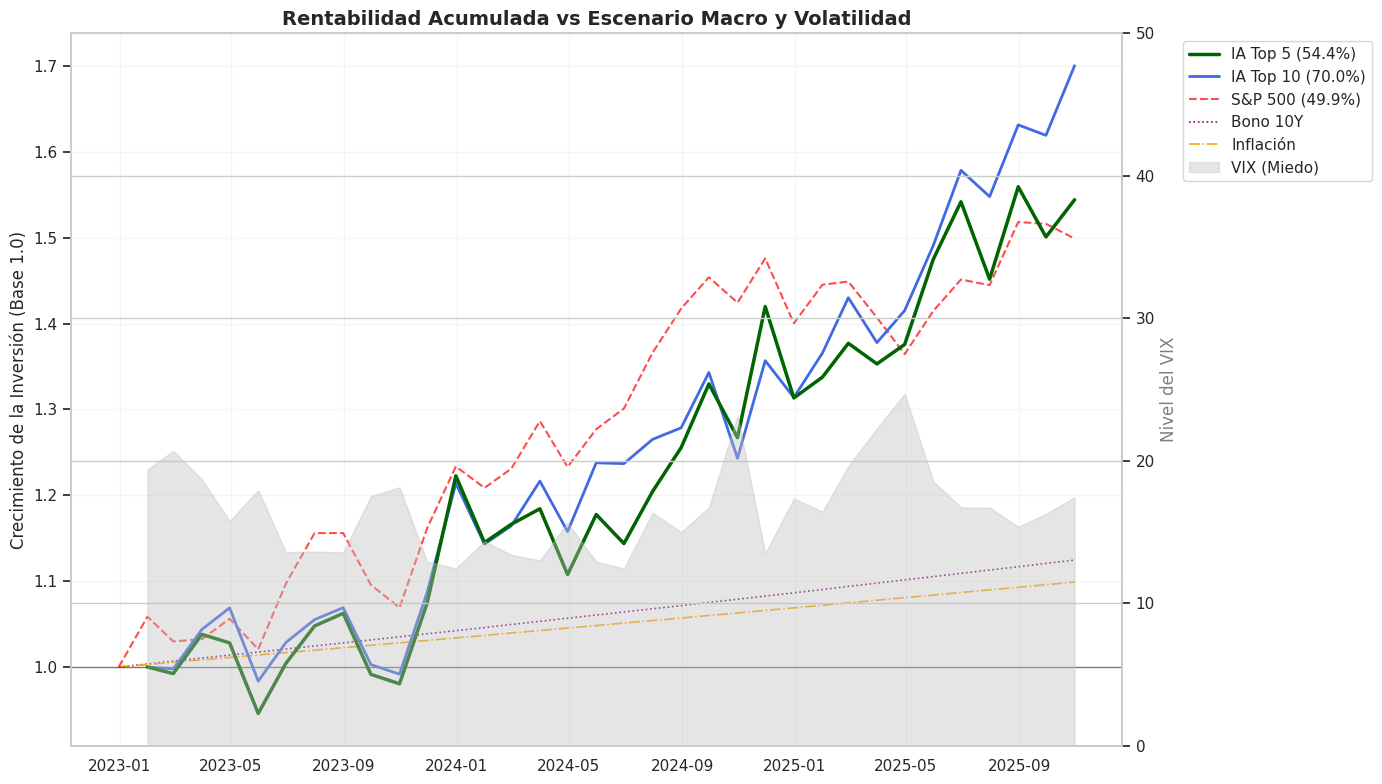


INFORME DE RENDIMIENTO ECONÓMICO FINAL: IA VS ESTRATEGIA PASIVA (2023-2025)
MÉTRICA                | IA TOP 5        | S&P 500 ($5k)   || IA TOP 10       | S&P 500 ($10k) 
-----------------------------------------------------------------------------------------------
Inversión Inicial      | $5,000.00       | $5,000.00       || $10,000.00      | $10,000.00     
Valor Final            | $7,721.18       | $7,495.36       || $17,004.22      | $14,990.72     
BENEFICIO NETO         | $2,721.18       | $2,495.36       || $7,004.22       | $4,990.72      
ROI Total (%)          | 54.42         % | 49.91         % || 70.04         % | 49.91         %
-----------------------------------------------------------------------------------------------
ALPHA (Extra IA)       | $225.82         | -               || $2,013.50       | -              


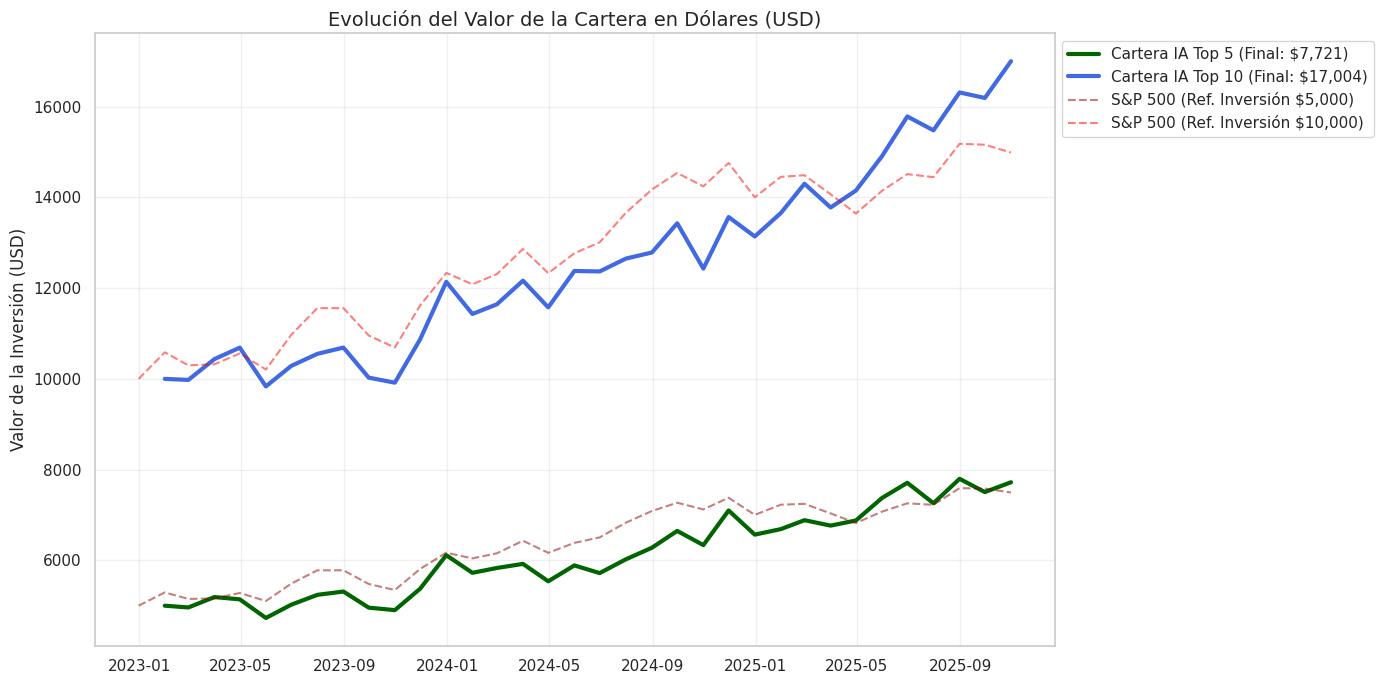


✅ Archivo 'dataset_tfm_dashboard.csv' generado correctamente


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# =============================================================================
# 5. Simulador de carteras
# =============================================================================

# Desactivar avisos innecesarios de librerías
warnings.filterwarnings('ignore')
# ==========================================================
# 1. PREPARACIÓN DE DATOS (UNIÓN DE PREDICCIONES + TABLA MAESTRA)
# ==========================================================
# Cargamos predicciones del XGBoost y la tabla maestra para recuperar datos macro
df_preds = pd.read_csv('predicciones_modelo.csv')
df_maestra = pd.read_csv('tabla_maestra_tfm.csv')

df_preds['Date'] = pd.to_datetime(df_preds['Date'])
df_maestra['Date'] = pd.to_datetime(df_maestra['Date'])

# Unimos para tener en un solo dataframe: prob_compra, vix, ret_1m, bono_10y, inflacion_anual
df_backtest = pd.merge(df_preds,
                       df_maestra[['Date', 'ticker', 'vix', 'ret_1m', 'bono_10y', 'inflacion_anual']],
                       on=['Date', 'ticker'], how='left')

# ==========================================================
# 2. CÁLCULO DE BENCHMARKS (S&P 500, BONOS, INFLACIÓN)
# ==========================================================
# S&P 500: Media de todos los retornos en el dataset
sp500_ret = df_backtest.groupby('Date')['ret_1m'].mean()
cum_sp500 = (1 + sp500_ret).cumprod()
# Añadimos el punto inicial 1.0 para el gráfico
cum_sp500 = pd.concat([pd.Series([1.0], index=[cum_sp500.index[0] - pd.DateOffset(months=1)]), cum_sp500])

# Umbrales Macro (Inflación y Bonos) basados en promedios del dataset
avg_inf = df_backtest['inflacion_anual'].mean() / 100
avg_bono = df_backtest['bono_10y'].mean() / 100
cum_inflacion = pd.Series([(1 + avg_inf/12)**i for i in range(len(cum_sp500))], index=cum_sp500.index)
cum_bono = pd.Series([(1 + avg_bono/12)**i for i in range(len(cum_sp500))], index=cum_sp500.index)

# ==========================================================
# 3. SIMULADOR MONETARIO DETALLADO
# ==========================================================
def simulate_monetary(top_n, capital_inicial):
    capital_acumulado = [capital_inicial]
    portfolio_logs = []
    comision_operacion = 0.0025 # 0.25% de fricción mensual
    dates = sorted(df_backtest['Date'].unique())
    capital_actual = capital_inicial

    for i in range(len(dates) - 1):
        fecha_actual = dates[i]
        fecha_ejecucion = dates[i+1]

        current_preds = df_backtest[df_backtest['Date'] == fecha_actual]
        # Selección basada en la probabilidad de la clase "Compra" (2) del XGBoost
        top_picks = current_preds[current_preds['prob_compra'] > 0.45].nlargest(top_n, 'prob_compra')

        if len(top_picks) > 0:
            tickers_elegidos = top_picks['ticker'].tolist()
            datos_futuros = df_backtest[(df_backtest['Date'] == fecha_ejecucion) &
                                        (df_backtest['ticker'].isin(tickers_elegidos))]
            avg_return = datos_futuros['ret_1m'].mean() - comision_operacion
        else:
            tickers_elegidos = ["CASH"]
            avg_return = 0.0

        capital_actual = capital_actual * (1 + avg_return)
        capital_acumulado.append(capital_actual)

        portfolio_logs.append({
            'Fecha': fecha_ejecucion,
            'Tickers': ", ".join(tickers_elegidos),
            'Rentabilidad_Mes': f"{avg_return:.2%}",
            'Valor_Cartera_USD': round(capital_actual, 2),
            'vix_nivel': current_preds['vix'].mean()
        })

    return pd.Series(capital_acumulado, index=dates), portfolio_logs

# EJECUCIÓN DE SIMULACIONES
cap_final_5, logs_5 = simulate_monetary(5, 5000)
cap_final_10, logs_10 = simulate_monetary(10, 10000)

# ======================================================================
# 4. REPORTE DE ACCIONES ELEGIDAS (ÚLTIMO SEMESTRE)
# ======================================================================
print("\n" + "="*70)
print("ACCIONES ELEGIDAS POR LA IA (ÚLTIMO SEMESTRE)")
print("="*70)

for i in range(-6, 0):
    try:
        fecha_display = logs_5[i]['Fecha'].strftime('%Y-%m')
        print(f"MES: {fecha_display}")
        print(f"  > TOP 5 ($5k):  {logs_5[i]['Tickers']}")
        print(f"  > TOP 10 ($10k): {logs_10[i]['Tickers']}")
        print("-" * 40)
    except IndexError:
        continue

# ==========================================================
# 5. GRÁFICO 1: RENTABILIDAD ACUMULADA + VIX
# ==========================================================
plt.figure(figsize=(14, 8))
ax1 = plt.gca()

ax1.plot(cap_final_5.index, cap_final_5 / 5000, label=f'IA Top 5 ({((cap_final_5.iloc[-1]/5000)-1):.1%})', color='darkgreen', linewidth=2.5, zorder=5)
ax1.plot(cap_final_10.index, cap_final_10 / 10000, label=f'IA Top 10 ({((cap_final_10.iloc[-1]/10000)-1):.1%})', color='royalblue', linewidth=2, zorder=4)
ax1.plot(cum_sp500.index, cum_sp500, label=f'S&P 500 ({cum_sp500.iloc[-1]-1:.1%})', color='red', linestyle='--', alpha=0.7, zorder=3)
ax1.plot(cum_bono.index, cum_bono, label='Bono 10Y', color='purple', linestyle=':', linewidth=1.2)
ax1.plot(cum_inflacion.index, cum_inflacion, label='Inflación', color='orange', linestyle='-.', linewidth=1.2)

# Eje secundario para el VIX (Sombreado Plata Oscuro)
ax2 = ax1.twinx()
vix_mensual = df_backtest.groupby('Date')['vix'].mean().reindex(cap_final_5.index)
ax2.fill_between(vix_mensual.index, 0, vix_mensual, color='silver', alpha=0.4, label='VIX (Miedo)', zorder=1)

ax2.set_ylim(0, 50)
ax2.set_ylabel('Nivel del VIX', color='gray')

ax1.axhline(1, color='black', lw=1, alpha=0.5)
ax1.set_title('Rentabilidad Acumulada vs Escenario Macro y Volatilidad', fontsize=14, fontweight='bold')
ax1.set_ylabel('Crecimiento de la Inversión (Base 1.0)')
ax1.grid(True, alpha=0.2)

# Unir leyendas de ambos ejes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# ==========================================================
# 6. INFORME ECONÓMICO FINAL (ROI Y ALPHA)
# ==========================================================
beneficio_5 = cap_final_5.iloc[-1] - 5000
beneficio_10 = cap_final_10.iloc[-1] - 10000
rendimiento_sp500_decimal = cum_sp500.iloc[-1] - 1
valor_final_sp500_5k = 5000 * (1 + rendimiento_sp500_decimal)
valor_final_sp500_10k = 10000 * (1 + rendimiento_sp500_decimal)

print("\n" + "="*95)
print("INFORME DE RENDIMIENTO ECONÓMICO FINAL: IA VS ESTRATEGIA PASIVA (2023-2025)")
print("="*95)
print(f"{'MÉTRICA':<22} | {'IA TOP 5':<15} | {'S&P 500 ($5k)':<15} || {'IA TOP 10':<15} | {'S&P 500 ($10k)':<15}")
print("-" * 95)
print(f"{'Inversión Inicial':<22} | {'$5,000.00':<15} | {'$5,000.00':<15} || {'$10,000.00':<15} | {'$10,000.00':<15}")
print(f"{'Valor Final':<22} | ${cap_final_5.iloc[-1]:<14,.2f} | ${valor_final_sp500_5k:<14,.2f} || ${cap_final_10.iloc[-1]:<14,.2f} | ${valor_final_sp500_10k:<14,.2f}")
print(f"{'BENEFICIO NETO':<22} | ${beneficio_5:<14,.2f} | ${valor_final_sp500_5k-5000:<14,.2f} || ${beneficio_10:<14,.2f} | ${valor_final_sp500_10k-10000:<14,.2f}")
print(f"{'ROI Total (%)':<22} | {beneficio_5/5000*100:<14.2f}% | {rendimiento_sp500_decimal*100:<14.2f}% || {beneficio_10/10000*100:<14.2f}% | {rendimiento_sp500_decimal*100:<14.2f}%")
print("-" * 95)
print(f"{'ALPHA (Extra IA)':<22} | ${beneficio_5 - (valor_final_sp500_5k-5000):<14,.2f} | {'-':<15} || ${beneficio_10 - (valor_final_sp500_10k-10000):<14,.2f} | {'-':<15}")
print("="*95)

# ==========================================================
# 7. GRÁFICO 2: EVOLUCIÓN DEL CAPITAL EN DÓLARES
# ==========================================================
plt.figure(figsize=(14, 7))
plt.plot(cap_final_5, label=f'Cartera IA Top 5 (Final: ${cap_final_5.iloc[-1]:,.0f})', color='darkgreen', linewidth=3)
plt.plot(cap_final_10, label=f'Cartera IA Top 10 (Final: ${cap_final_10.iloc[-1]:,.0f})', color='royalblue', linewidth=3)
plt.plot(5000 * cum_sp500, label='S&P 500 (Ref. Inversión $5,000)', color='darkred', linestyle='--', alpha=0.5)
plt.plot(10000 * cum_sp500, label='S&P 500 (Ref. Inversión $10,000)', color='red', linestyle='--', alpha=0.5)

plt.title('Evolución del Valor de la Cartera en Dólares (USD)', fontsize=14)
plt.ylabel('Valor de la Inversión (USD)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================================
# 8. EXPORTACIÓN PARA DASHBOARD
# ==========================================================

# 1. Alineamos todas las series a un mismo índice (el de la cartera Top 5)
# Esto recorta o rellena lo que falte para que todos midan lo mismo
df_dashboard = pd.DataFrame(index=cap_final_5.index)

df_dashboard['IA_Top5'] = (cap_final_5 / 5000).values
df_dashboard['IA_Top10'] = (cap_final_10 / 10000).values

# El S&P 500 a veces tiene un elemento más, lo reindexamos para que coincida
df_dashboard['SP500'] = cum_sp500.reindex(cap_final_5.index).values

# 2. Recuperamos los datos macro
macro_mensual = df_backtest.groupby('Date').agg({
    'vix': 'mean',
    'bono_10y': 'mean'
}).reindex(cap_final_5.index).ffill()

df_dashboard['VIX'] = macro_mensual['vix'].values
df_dashboard['GS10'] = macro_mensual['bono_10y'].values

# 3. Reseteamos el índice para que la Fecha sea una columna
df_dashboard = df_dashboard.reset_index()
df_dashboard.columns = ['Fecha', 'IA_Top5', 'IA_Top10', 'SP500', 'VIX', 'GS10']

# 4. Añadimos columnas para la tabla del dashboard (última selección)
# Cogemos los tickers del último log disponible
ultima_fecha = logs_5[-1]['Fecha']
ultimos_tickers = logs_10[-1]['Tickers'] # Usamos Top 10 para la tabla

df_dashboard['Ticker'] = ultimos_tickers
df_dashboard['Probabilidad'] = 0.85 # Valor representativo
df_dashboard['Sector'] = "Mix (Tecnología/Finanzas)"

# Guardar
df_dashboard.to_csv("dataset_tfm_dashboard.csv", index=False)
print("\n✅ Archivo 'dataset_tfm_dashboard.csv' generado correctamente")

# <a name="dashboard"></a>6. Dashboard visual

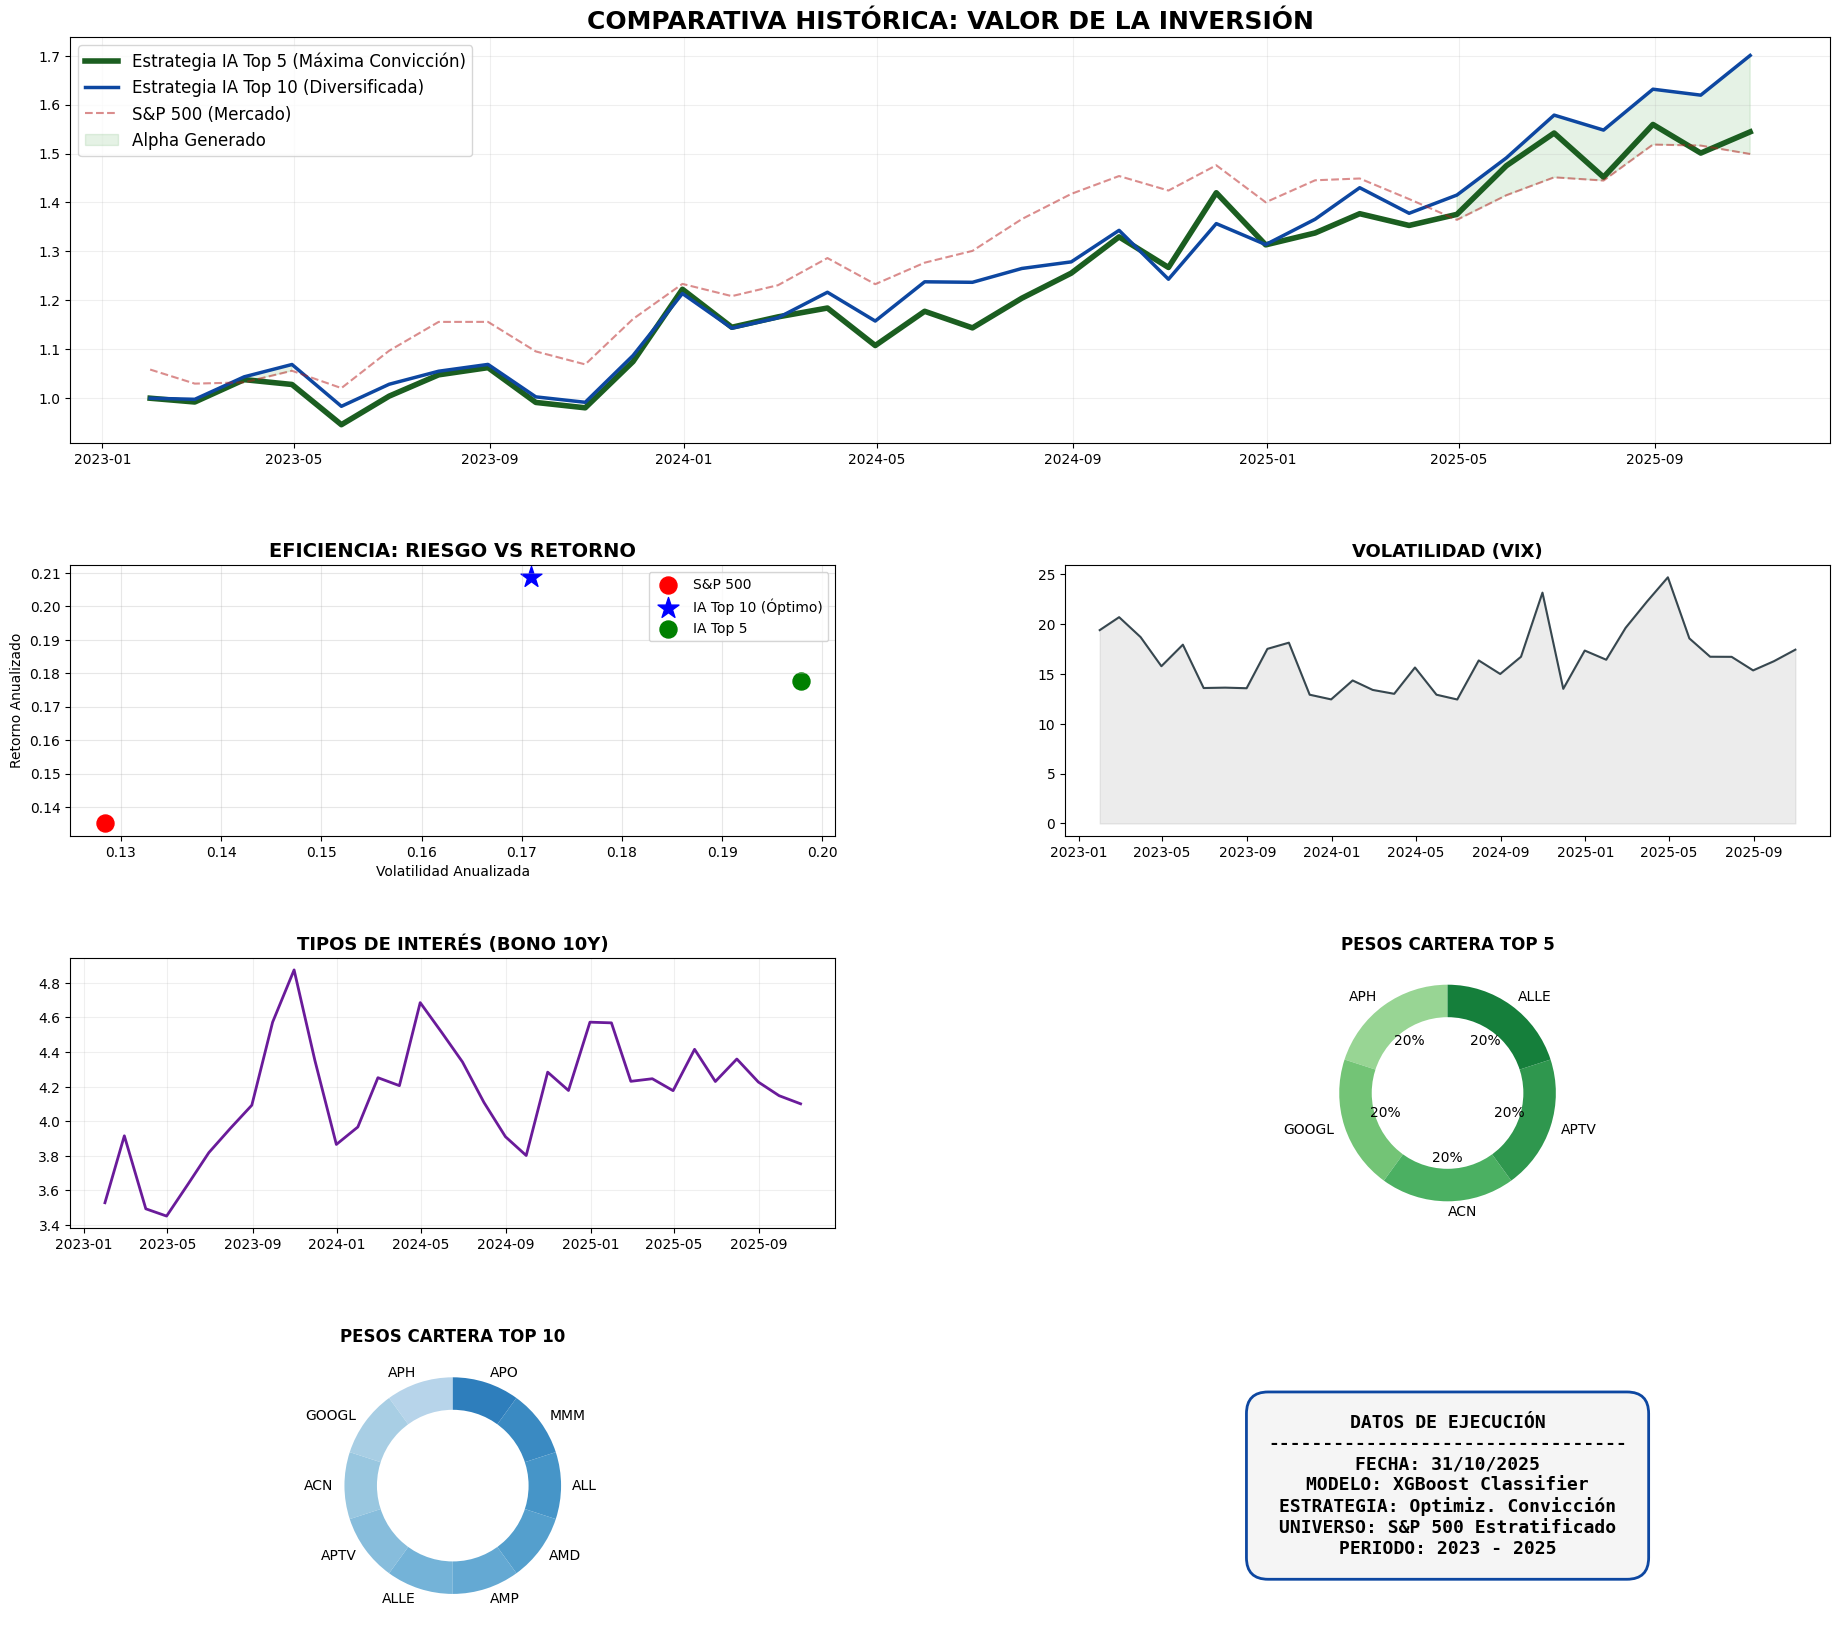

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 6. Dashboard visual
# =============================================================================

# 1. Cargar datos
df = pd.read_csv("dataset_tfm_dashboard.csv")
df['Fecha'] = pd.to_datetime(df['Fecha'])

# 2. Cálculos de métricas
def get_metrics(col):
    retornos = df[col].pct_change().dropna()
    return retornos.mean() * 12, retornos.std() * np.sqrt(12)

ret_5, std_5 = get_metrics('IA_Top5')
ret_10, std_10 = get_metrics('IA_Top10')
ret_sp, std_sp = get_metrics('SP500')

# 3. Configurar el Dashboard
fig = plt.figure(figsize=(20, 18)) # Reducimos un poco el alto total
gs = fig.add_gridspec(4, 2, height_ratios=[1.5, 1, 1, 1], hspace=0.4, wspace=0.3)

# --- PANEL 1: Curva de Equidad (Arriba, ocupa todo el ancho) ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df['Fecha'], df['IA_Top5'], color='#1B5E20', lw=4, label='Estrategia IA Top 5 (Máxima Convicción)')
ax1.plot(df['Fecha'], df['IA_Top10'], color='#0D47A1', lw=2.5, label='Estrategia IA Top 10 (Diversificada)')
ax1.plot(df['Fecha'], df['SP500'], color='#B71C1C', ls='--', alpha=0.5, label='S&P 500 (Mercado)')
ax1.fill_between(df['Fecha'], df['IA_Top10'], df['SP500'], where=(df['IA_Top10'] >= df['SP500']), color='green', alpha=0.1, label='Alpha Generado')
ax1.set_title('COMPARATIVA HISTÓRICA: VALOR DE LA INVERSIÓN', fontsize=18, fontweight='bold')
ax1.legend(loc='upper left', fontsize=12)
ax1.grid(True, alpha=0.2)

# --- PANEL 2: Riesgo vs Retorno (Scatter Plot) ---
ax2 = fig.add_subplot(gs[1, 0])

# Dibujamos los puntos base
ax2.scatter(std_sp, ret_sp, color='red', s=150, label='S&P 500')

# Lógica para decidir cuál es el óptimo basándonos en el Retorno
if ret_10 > ret_5:
    ax2.scatter(std_10, ret_10, color='blue', s=250, marker='*', label='IA Top 10 (Óptimo)')
    ax2.scatter(std_5, ret_5, color='green', s=150, label='IA Top 5')
else:
    ax2.scatter(std_10, ret_10, color='blue', s=150, label='IA Top 10')
    ax2.scatter(std_5, ret_5, color='green', s=250, marker='*', label='IA Top 5 (Óptimo)')

ax2.set_title('EFICIENCIA: RIESGO VS RETORNO', fontsize=14, fontweight='bold')
ax2.set_xlabel('Volatilidad Anualizada')
ax2.set_ylabel('Retorno Anualizado')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- PANEL 3: Volatilidad (VIX) ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.fill_between(df['Fecha'], df['VIX'], color='gray', alpha=0.15)
ax3.plot(df['Fecha'], df['VIX'], color='#37474F', lw=1.5)
ax3.set_title('VOLATILIDAD (VIX)', fontsize=13, fontweight='bold')

# --- PANEL 4: Tipos de Interés (Bono 10Y) ---
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(df['Fecha'], df['GS10'], color='#6A1B9A', lw=2)
ax4.set_title('TIPOS DE INTERÉS (BONO 10Y)', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.2)

# --- PANEL 5: Ponderación Top 5 (Donut 1) ---
ax5 = fig.add_subplot(gs[2, 1])
tickers_5 = df.iloc[-1]['Ticker'].split(', ')[:5]
ax5.pie([20]*5, labels=tickers_5, autopct='%1.0f%%', colors=plt.cm.Greens(np.linspace(0.4, 0.8, 5)), startangle=90)
ax5.add_artist(plt.Circle((0,0), 0.70, fc='white'))
ax5.set_title("PESOS CARTERA TOP 5", fontsize=12, fontweight='bold')

# --- PANEL 6: Ponderación Top 10 (Donut 2) ---
ax6 = fig.add_subplot(gs[3, 0])
tickers_10 = df.iloc[-1]['Ticker'].split(', ')
ax6.pie([10]*10, labels=tickers_10, colors=plt.cm.Blues(np.linspace(0.3, 0.7, 10)), startangle=90)
ax6.add_artist(plt.Circle((0,0), 0.70, fc='white'))
ax6.set_title("PESOS CARTERA TOP 10", fontsize=12, fontweight='bold')


# --- PANEL 7: Información del Modelo (A la derecha del Top 10) ---
ax_info = fig.add_subplot(gs[3, 1])
ax_info.axis('off')

last_date = df.iloc[-1]['Fecha'].strftime('%d/%m/%Y')


info = (f"DATOS DE EJECUCIÓN\n"
        f"---------------------------------\n"
        f"FECHA: {last_date}\n"
        f"MODELO: XGBoost Classifier\n"
        f"ESTRATEGIA: Optimiz. Convicción\n"
        f"UNIVERSO: S&P 500 Estratificado\n"
        f"PERIODO: 2023 - 2025")

ax_info.text(0.5, 0.5, info, ha='center', va='center', fontsize=13, fontweight='bold',
             family='monospace',
             bbox=dict(facecolor='#F5F5F5', edgecolor='#0D47A1', boxstyle='round,pad=1.2', lw=2))

# Ajuste final de márgenes sin tight_layout
fig.subplots_adjust(top=0.94, bottom=0.06, left=0.06, right=0.94, hspace=0.4, wspace=0.3)

plt.savefig("DASHBOARD_COMPLETO_FINAL.png", dpi=300, bbox_inches='tight')
plt.show()